In [11]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from itertools import product

In [ ]:
G = 9.81
V_MAX = 25.0
T = V_MAX / G
L = V_MAX ** 2 / G


def rhs(t, z, k):
    _, _, vx, vy = z
    v = np.sqrt(vx * vx + vy * vy)
    return vx, vy, -k * t * v * vx, -G - k * t * v * vy


def simulate(k, v, alpha, n_points=200, t_max=60):
    def hit_ground(t, z):
        return z[1]
    
    setattr(hit_ground, "terminal", True)
    setattr(hit_ground, "direction", -1)

    sol = solve_ivp(
        lambda t, z: rhs(t, z, k),
        t_span=(0, t_max),
        y0=(0, 0, v * np.cos(alpha), v * np.sin(alpha)),
        method='RK45',
        dense_output=True,
        events=hit_ground,
        rtol=1e-9,
        atol=1e-9,
    )
    t_end = sol.t_events[0][0] if len(sol.t_events[0]) > 0 else sol.t[-1]
    t = np.linspace(0, t_end, n_points)
    x, y, vx, vy = sol.sol(t)

    return {
        "t": t,
        "x": x,
        "y": y,
        "vx": vx,
        "vy": vy,
        "k": k,
        "alpha": alpha,
        "v": v,
    }


def make_trajectory_dataset(
    n_traj=2000,
    n_points=80,
    n_obs=12,
    noise_std=0.1,
    seed=0,
    alpha_range=(np.pi / 12, np.pi * 5 / 12),
    v_range=(1.0, 25.0),
    k_range=(1e-3, 2.5e-3),
):
    rng = np.random.default_rng(seed)

    X = np.zeros((n_traj, n_obs, 3), dtype=np.float32)  # (x, y, t)
    y = np.zeros((n_traj, 3), dtype=np.float32)  # (alpha, v, k)

    for j in range(n_traj):
        alpha = rng.uniform(*alpha_range)
        v = rng.uniform(*v_range)
        k = rng.uniform(*k_range)

        sim = simulate(k, v, alpha, n_points=n_points)

        x = sim["x"].copy()
        y_pos = sim["y"].copy()
        t = sim["t"].copy()

        if noise_std > 0:
            x += rng.normal(0.0, noise_std, size=x.shape)
            y_pos += rng.normal(0.0, noise_std, size=y_pos.shape)
    
        idx = np.sort(rng.choice(len(t), size=n_obs, replace=False))

        X[j, :, 0] = x[idx]
        X[j, :, 1] = y_pos[idx]
        X[j, :, 2] = t[idx]

        y[j, 0] = alpha
        y[j, 1] = v
        y[j, 2] = k

    return X, y


In [ ]:
class DeepSetsInverseNet(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.point = nn.Sequential(
            nn.Linear(3, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 3),
        )

        self.alpha_min, self.alpha_max = np.pi / 12, np.pi * 5 / 12
        self.v_min, self.v_max = 1.0, 25.0
        self.k_min, self.k_max = 5e-4, 2.5e-3

    def encode(self, obs):
        # obs: [B, n_obs, 3]
        x = obs[..., 0] / L
        y = obs[..., 1] / L
        tau = obs[..., 2] / T

        pts = torch.stack([x, y, tau], dim=-1) # [B, n, 3]
        h = self.point(pts) # [B, n, H]
        h = h.mean(dim=1) # [B, H]
        return h

    def forward01(self, obs):
        h = self.encode(obs)
        raw = self.head(h) # [B, 3]
        return torch.sigmoid(raw)

    def forward(self, obs):
        """Return physical parameters: (alpha, v, k)."""
        s01 = self.forward01(obs)
        a01, v01, k01 = s01[:, 0], s01[:, 1], s01[:, 2]

        alpha = (self.alpha_min + (self.alpha_max - self.alpha_min) * a01).to(obs.dtype)
        v0 = (self.v_min + (self.v_max - self.v_min) * v01).to(obs.dtype)
        k = (self.k_min + (self.k_max - self.k_min) * k01).to(obs.dtype)

        return torch.stack([alpha, v0, k], dim=1)



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X, y = make_trajectory_dataset(n_traj=4000, n_points=80, n_obs=12, noise_std=0.1, seed=42)

X_t = torch.from_numpy(X)
Y_t = torch.from_numpy(y)

alpha_min, alpha_max = np.pi / 12, np.pi * 5 / 12
v_min, v_max = 1.0, 25.0
k_min, k_max = 1e-3, 2.5e-3

Y01 = torch.empty_like(Y_t)
Y01[:, 0] = (Y_t[:, 0] - alpha_min) / (alpha_max - alpha_min)
Y01[:, 1] = (Y_t[:, 1] - v_min) / (v_max - v_min)
Y01[:, 2] = (Y_t[:, 2] - k_min) / (k_max - k_min)


n = X_t.shape[0]
perm = torch.randperm(n)
split = int(0.85 * n)
tr_idx, va_idx = perm[:split], perm[split:]

train_ds = torch.utils.data.TensorDataset(X_t[tr_idx], Y01[tr_idx], Y_t[tr_idx])
val_ds = torch.utils.data.TensorDataset(X_t[va_idx], Y01[va_idx], Y_t[va_idx])

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=512, shuffle=False)

model = DeepSetsInverseNet(hidden=128).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=0.0)
base_loss = nn.SmoothL1Loss(reduction='none')

loss_w = torch.tensor([1.0, 2.0, 1.0], dtype=torch.float32, device=device)

for epoch in range(60):
    model.train()
    tr_loss = 0.0
    for xb, y01b, yb in train_loader:
        xb = xb.to(device)
        y01b = y01b.to(device)

        pred01 = model.forward01(xb)
        per_dim = base_loss(pred01, y01b)
        loss = (per_dim * loss_w).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()
        tr_loss += loss.item() * xb.size(0)

    model.eval()
    va_loss = 0.0
    with torch.no_grad():
        for xb, y01b, yb in val_loader:
            xb = xb.to(device)
            y01b = y01b.to(device)
            pred01 = model.forward01(xb)
            per_dim = base_loss(pred01, y01b)
            va_loss += (per_dim * loss_w).mean().item() * xb.size(0)

    tr_loss /= len(train_ds)
    va_loss /= len(val_ds)
    print(f"epoch={epoch:03d} train01={tr_loss:.5f} val01={va_loss:.5f}")


epoch=000 train01=0.04724 val01=0.03557
epoch=001 train01=0.03368 val01=0.03311
epoch=002 train01=0.03068 val01=0.02978
epoch=003 train01=0.02632 val01=0.02496
epoch=004 train01=0.02193 val01=0.02203
epoch=005 train01=0.02045 val01=0.02131
epoch=006 train01=0.01979 val01=0.02038
epoch=007 train01=0.01930 val01=0.01996
epoch=008 train01=0.01899 val01=0.01947
epoch=009 train01=0.01856 val01=0.01898
epoch=010 train01=0.01813 val01=0.01856
epoch=011 train01=0.01792 val01=0.01841
epoch=012 train01=0.01762 val01=0.01815
epoch=013 train01=0.01745 val01=0.01801
epoch=014 train01=0.01726 val01=0.01782
epoch=015 train01=0.01706 val01=0.01759
epoch=016 train01=0.01693 val01=0.01743
epoch=017 train01=0.01691 val01=0.01786
epoch=018 train01=0.01695 val01=0.01734
epoch=019 train01=0.01691 val01=0.01708
epoch=020 train01=0.01662 val01=0.01732
epoch=021 train01=0.01664 val01=0.01699
epoch=022 train01=0.01647 val01=0.01699
epoch=023 train01=0.01632 val01=0.01678
epoch=024 train01=0.01612 val01=0.01661


true  (alpha, v, k): 0.7853981633974483 18.0 0.0015
pred  (alpha, v, k): 0.7630859017372131 18.14499855041504 0.0014628039207309484


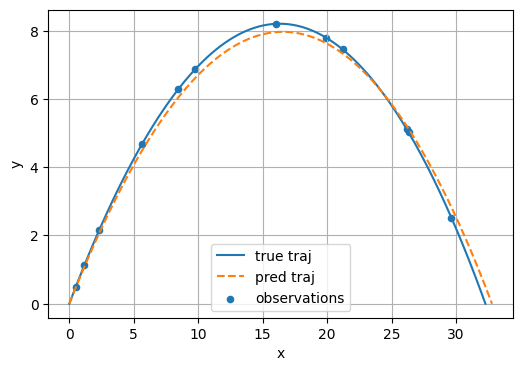

In [13]:
import matplotlib.pyplot as plt

# --- Quick sanity-check on one random trajectory ---

# ground-truth parameters
alpha_true = float(np.pi / 4)
v_true = 18.0
k_true = 1.5e-3

sim_true = simulate(k_true, v_true, alpha_true, n_points=200)

# take n_obs triples (x, y, t)
rng = np.random.default_rng(0)
n_obs = 12
idx = np.sort(rng.choice(len(sim_true["t"]), size=n_obs, replace=False))
obs = np.stack([sim_true["x"][idx], sim_true["y"][idx], sim_true["t"][idx]], axis=-1).astype(np.float32)

with torch.no_grad():
    pred = model(torch.from_numpy(obs[None, ...]).to(device)).cpu().numpy()[0]

alpha_hat, v_hat, k_hat = map(float, pred)
print("true  (alpha, v, k):", alpha_true, v_true, k_true)
print("pred  (alpha, v, k):", alpha_hat, v_hat, k_hat)

sim_hat = simulate(k_hat, v_hat, alpha_hat, n_points=200)

plt.figure(figsize=(6, 4))
plt.plot(sim_true["x"], sim_true["y"], label="true traj")
plt.plot(sim_hat["x"], sim_hat["y"], "--", label="pred traj")
plt.scatter(sim_true["x"][idx], sim_true["y"][idx], s=20, label="observations")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

unperturbed true (alpha, v, k): 0.7853981633974483 18.0 0.0
model pred        (alpha, v, k): 0.7469967007637024 18.317947387695312 0.0014539840631186962


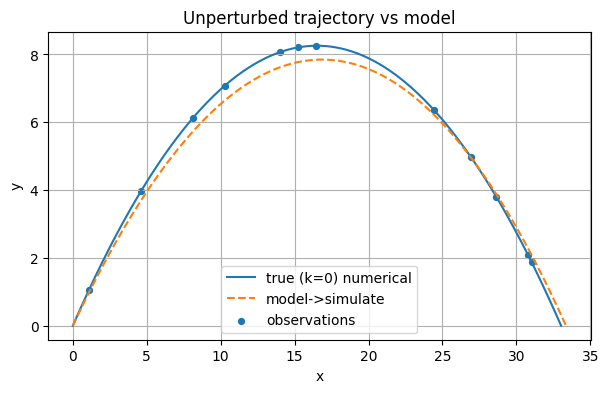

In [14]:
alpha0 = np.pi / 4
v0 = 18.0
k0 = 0.0  # Невозмущенная задача

sim0 = simulate(k0, v0, alpha0, n_points=400)

rng = np.random.default_rng(1)
n_obs = 12
idx = np.sort(rng.choice(len(sim0["t"]), size=n_obs, replace=False))
obs0 = np.stack([sim0["x"][idx], sim0["y"][idx], sim0["t"][idx]], axis=-1).astype(np.float32)

with torch.no_grad():
    pred = model(torch.from_numpy(obs0[None, ...]).to(device)).cpu().numpy()[0]

alpha_hat, v_hat, k_hat = map(float, pred)

sim_hat = simulate(k_hat, v_hat, alpha_hat, n_points=400)

print("unperturbed true (alpha, v, k):", alpha0, v0, k0)
print("model pred        (alpha, v, k):", alpha_hat, v_hat, k_hat)

plt.figure(figsize=(7, 4))
plt.plot(sim0["x"], sim0["y"], label="true (k=0) numerical")
plt.plot(sim_hat["x"], sim_hat["y"], "--", label="model->simulate")
plt.scatter(sim0["x"][idx], sim0["y"][idx], s=18, label="observations")
plt.title("Unperturbed trajectory vs model")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

Validation errors:
alpha: MAE=0.038497 rad, RMSE=0.073180 rad
v    : MAE=0.401241, RMSE=0.517169
k    : MAE=0.00044853, RMSE=0.00053548


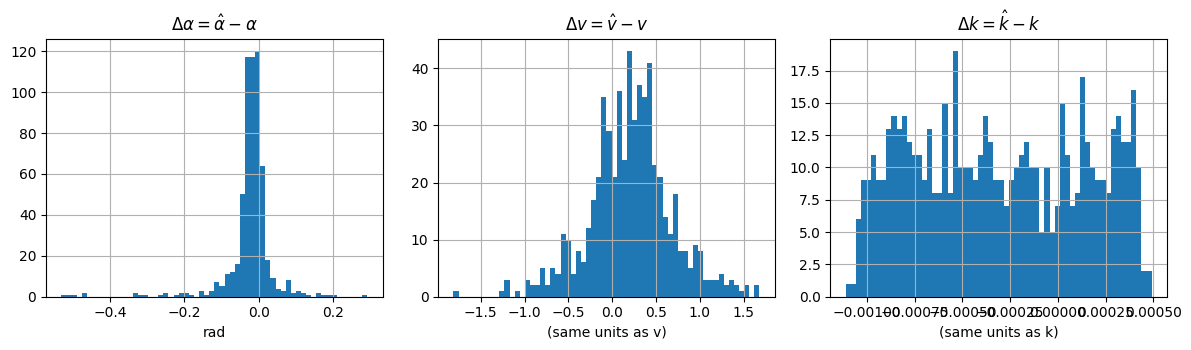

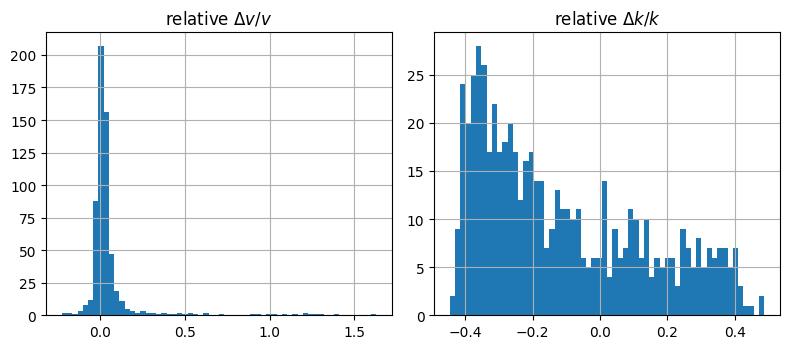

In [16]:
model.eval()

alpha_err = []
v_err = []
k_err = []

with torch.no_grad():
    for xb, y01b, yb in val_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb)  # (alpha, v, k)

        alpha_err.append((pred[:, 0] - yb[:, 0]).cpu().numpy())
        v_err.append((pred[:, 1] - yb[:, 1]).cpu().numpy())
        k_err.append((pred[:, 2] - yb[:, 2]).cpu().numpy())

alpha_err = np.concatenate(alpha_err)
v_err = np.concatenate(v_err)
k_err = np.concatenate(k_err)

# metrics
mae_alpha = np.mean(np.abs(alpha_err))
rmse_alpha = float(np.sqrt(np.mean(alpha_err ** 2)))
mae_v = np.mean(np.abs(v_err))
rmse_v = float(np.sqrt(np.mean(v_err ** 2)))
mae_k = np.mean(np.abs(k_err))
rmse_k = float(np.sqrt(np.mean(k_err ** 2)))

print("Validation errors:")
print(f"alpha: MAE={mae_alpha:.6f} rad, RMSE={rmse_alpha:.6f} rad")
print(f"v    : MAE={mae_v:.6f}, RMSE={rmse_v:.6f}")
print(f"k    : MAE={mae_k:.8f}, RMSE={rmse_k:.8f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].hist(alpha_err, bins=60)
axes[0].set_title(r"$\Delta \alpha = \hat\alpha-\alpha$")
axes[0].set_xlabel("rad")
axes[0].grid(True)

axes[1].hist(v_err, bins=60)
axes[1].set_title(r"$\Delta v = \hat v - v$")
axes[1].set_xlabel("(same units as v)")
axes[1].grid(True)

axes[2].hist(k_err, bins=60)
axes[2].set_title(r"$\Delta k = \hat k - k$")
axes[2].set_xlabel("(same units as k)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

rel_v = v_err / (np.abs(v_err - v_err + 1.0))

v_true = []
k_true = []
with torch.no_grad():
    for xb, y01b, yb in val_loader:
        v_true.append(yb[:, 1].cpu().numpy())
        k_true.append(yb[:, 2].cpu().numpy())

v_true = np.concatenate(v_true)
k_true = np.concatenate(k_true)

rel_v = v_err / v_true
rel_k = k_err / k_true

fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
axes[0].hist(rel_v, bins=60)
axes[0].set_title(r"relative $\Delta v / v$")
axes[0].grid(True)

axes[1].hist(rel_k, bins=60)
axes[1].set_title(r"relative $\Delta k / k$")
axes[1].grid(True)

plt.tight_layout()
plt.show()